用卷积神经网络去编辑生成器和判别器

In [17]:
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets
import torch

DCGAN 官方规定：

G：每层都加 BatchNorm（除了第一层和最后一层）

D：每层都加 BatchNorm（除了第一层和最后一层）

因为：

没有 BN → 判别器太强 → G 崩溃（collapse）

尤其是 CIFAR10 → 很容易训练不稳定

In [107]:
class dcGenerator(nn.Module):
    def __init__(self):
        super(dcGenerator, self).__init__()
        self.main = nn.Sequential(
            # nn.ConvTranspose2d(100,256,kernel_size=3,stride=2,bias=False),
            # nn.ReLU(),
            # #1,1->3,3
            # nn.ConvTranspose2d(256,128,kernel_size=3,stride=2,bias=False),
            # nn.ReLU(),#3,3->7,7
            # nn.ConvTranspose2d(128,64,kernel_size=3,stride=2,bias=False),
            # nn.ReLU(),#7,7->15,15
            # nn.ConvTranspose2d(64,3,kernel_size=4,stride=2,bias=False),#15,15->32，32
            # nn.Tanh()
            
            #下面是官方的dcgan的shape
            nn.ConvTranspose2d(100, 256, kernel_size=4, stride=1, padding=0),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()

        )
    def forward(self,x):
        return self.main(x)

class dcDiscriminator(nn.Module):
    def __init__(self):
        super(dcDiscriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3,64,kernel_size=4,stride=2,padding=1,bias=False),
            nn.LeakyReLU(0.2),#32,32->16,16
            nn.Conv2d(64,128,kernel_size=4,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),#16,16->8，8
            nn.Conv2d(128,256,kernel_size=4,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),#8，8->4,4
            nn.Conv2d(256,1,kernel_size=4,stride=1,padding=0,bias=False),
            nn.Sigmoid()#3,3->1,1
        )

    def forward(self,x):
        output=self.main(x)
        return output.view(x.shape[0],-1)

In [108]:
def weights_init(model):
    classname = model.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(model.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(model.weight.data, 1.0, 0.02)
        nn.init.constant_(model.bias.data, 0)

处理彩色图片要对三通道进行处理

In [129]:
transform = transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))#注意这里要是三通道
    
])
train_dataset=torchvision.datasets.CIFAR10(root='.',train=True,transform=transform,download=True)
Cifar_classes=train_dataset.classes
test_dataset=torchvision.datasets.CIFAR10(root='.',train=True,transform=transform,download=True)
train_loader=torch.utils.data.DataLoader(dataset=train_dataset,batch_size=256,shuffle=True,num_workers=8,pin_memory=True)
test_loader=torch.utils.data.DataLoader(dataset=test_dataset,batch_size=64,shuffle=True)

In [110]:
device="cuda" if torch.cuda.is_available() else "cpu"
dc_generator=dcGenerator().to(device)
dc_discriminator=dcDiscriminator().to(device)
weights_init(dc_generator)
weights_init(dc_discriminator)


model = (dc_generator,dc_discriminator)


In [120]:
optimizer_dcG=torch.optim.Adam(dc_generator.parameters(),lr=0.0002,betas=(0.5,0.999))
optimizer_dcD=torch.optim.Adam(dc_discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))
optimizer=(optimizer_dcG,optimizer_dcD)

In [127]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy
def train(model,optimizer,train_loader,device,epochs):
    dc_generator,dc_discriminator=model
    optimizer_dcG,optimizer_dcD=optimizer
    for epoch in range(epochs):

        for i,(images,_) in enumerate(train_loader):
            images=images.to(device)

            #先训练判别器
            dc_discriminator.train()
            optimizer_dcD.zero_grad()
            
            real_label=torch.ones(images.shape[0],1).to(device)*0.9
            fake_label=torch.zeros(images.shape[0],1).to(device)+0.1
            
            disc_real=dc_discriminator(images)
            loss_real=F.binary_cross_entropy(disc_real,real_label)
            
            noise=torch.randn(images.shape[0],100,1,1).to(device)
            gn_images=dc_generator(noise)
            disc_fake=dc_discriminator(gn_images.detach())
            loss_fake=torch.functional.F.binary_cross_entropy(disc_fake,fake_label)

            loss_total=(loss_real+loss_fake)/2

            loss_total.backward()
            optimizer_dcD.step()
            
            #训练生成器
            dc_generator.train()
            optimizer_dcG.zero_grad()
            
            
            # print(gn_images.shape)
            #生成一个图像
            predict_gn=dc_discriminator(gn_images)
            #算是生成图像的概率
            # print(predict_gn.shape)
            loss_gn=F.binary_cross_entropy(predict_gn,real_label)
            loss_gn.backward()
            optimizer_dcG.step()

            

            if i%1000==0:
                print("epoch:{},step:{},生成器损失:{},判别器损失:{}".format(epoch,i,loss_gn.item(),loss_total.item()))

                dc_generator.eval()
                noise = torch.randn(10, 100, 1, 1).to(device)
                imgs = dc_generator(noise).detach().cpu()
                fig, ax = plt.subplots(1, 10)
                for i, im in enumerate(imgs):
                    ax[i].imshow(((im.permute(1,2,0) + 1) / 2).cpu().numpy())

                plt.show()


In [ ]:

                noise = torch.randn(10, 100, 1, 1).to(device)
                imgs = dc_generator(noise).detach().cpu()
                fig, ax = plt.subplots(1, 10)
                for i, im in enumerate(imgs):
                    ax[i].imshow(((im.permute(1,2,0) + 1) / 2).cpu().numpy())

                plt.show()

In [ ]:
torch.backends.cudnn.benchmark = True
train(model,optimizer,train_loader,device,epochs=100)

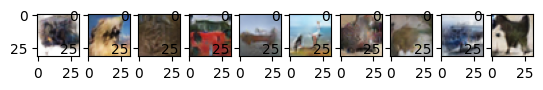

In [133]:
dc_generator.eval()
noise = torch.randn(10, 100, 1, 1).to(device)
imgs = dc_generator(noise).detach().cpu()
fig, ax = plt.subplots(1, 10)
for i, im in enumerate(imgs):
    ax[i].imshow(((im.permute(1,2,0) + 1) / 2).cpu().numpy())

plt.show()

最后展示图片的时候，注意从-1到1，还原成0-1

总结一下，以后训练一定要开num_workers=8，pin_memory=True，训练的巨快，torch.backends.cudnn.benchmark = True加速卷积，太叼了。

我给你按模块逐条指出问题和改进方案，你照着改性能直接提升一个档次。

✅ 1. Generator / Discriminator 网络结构问题
✔ 优点

结构大体 OK，有 DCGAN 风格。

❗需要改进
（1）Generator 最后的输出形状 不是标准的 32×32

你现在的尺寸变换：

100 → (3×3)
→ (7×7)
→ (15×15)
→ (32×32) ✔


这个能输出 32×32，但第一层 kernel=3 stride=2 会导致 非标准的 DCGAN shape，而且没有 padding 会让学习变难。

DCGAN 标准做法是这样：

100 → 4×4
→ 8×8
→ 16×16
→ 32×32


这里你最好改成官方模式：
```
nn.ConvTranspose2d(100, 256, kernel_size=4, stride=1, padding=0)
nn.ReLU(),

nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
nn.ReLU(),

nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
nn.ReLU(),

nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1)
nn.Tanh()
```

➡ 训练更稳定、图像质量会显著提高。

✅ 2. Discriminator 的卷积没有 padding

你的 D：
```
nn.Conv2d(3, 64, kernel_size=3, stride=2, bias=False)

```
没有 padding → 每层都在无意义地裁剪图片
这会：

难学

判别器变成 "盲人"，损失不稳定

生成器 collapse

应该改成：

nn.Conv2d(3, 64, 4, 2, 1)


跟 DCGAN 标准一样。

改完尺寸变化才会是：

32 → 16 → 8 → 4 → 1

❗3. 你的训练顺序是反的

你写的是：

先训练生成器 G
再训练判别器 D


这是 完全错误的 GAN 训练顺序。

正确顺序永远是：

更新 D

更新 G

要训练 D 时：

使用 real 图像（判真）

使用 detach() 的 fake 图像（判假）

要训练 G 时：

让 D.eval() 是正确的，但是

损失函数必须是：
```
loss_g = BCELoss(D(G(z)), real_label)
```
❗4. 你的 BCE 损失写法是错误的

你写：
```
torch.functional.F.binary_cross_entropy

```
F 不在 torch.functional！

正确的是：
```
import torch.nn.functional as F

loss = F.binary_cross_entropy(...)

```
否则整个损失其实调用错了地方（你应该已经看到生成器 loss 很奇怪）。

❗5. CIFAR10 的 normalize 写错了

你写：
```
transforms.Normalize(mean=0.5, std=0.5)
```

但 CIFAR10 是 3 通道。

正确写法：
```
transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
```

否则颜色会炸。

❗6. 生成器可视化错误

你写：
```
ax[i].imshow(im[0])

```
im[0] 只显示了 R 通道（灰度红色图）

应该：
```
ax[i].imshow(np.transpose(im, (1,2,0)))
```